# 黄金价格预测 - 完整项目笔记本

**项目说明：** 本笔记本整合了黄金价格预测项目的完整流程

**运行说明：** 按顺序从上到下运行每个单元格

---

**目录**
1. 环境配置与库导入
2. 数据采集/生成
3. 数据预处理
4. 探索性数据分析（EDA）
5. 基线模型（线性回归、多项式回归、Ridge回归）
6. 深度学习模型（LSTM、GRU）

## 第一部分：环境配置与库导入

In [1]:
import os, pickle, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures, MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

matplotlib.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
matplotlib.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 5)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

DATA_DIR   = '../data'
RAW_DIR    = '../data/raw'
PROC_DIR   = '../data/processed'
FIG_DIR    = '../outputs/figures'
MODEL_DIR  = '../outputs/models'
for d in [RAW_DIR, PROC_DIR, FIG_DIR, MODEL_DIR]:
    os.makedirs(d, exist_ok=True)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"PyTorch {torch.__version__}, device={DEVICE}")

PyTorch 2.10.0+cpu, device=cpu


## 第二部分：数据采集与生成

本项目支持两种数据来源：
- **方式A（推荐）**：从 Yahoo Finance 下载真实金融数据
- **方式B（备用）**：自动生成模拟数据（网络受限时使用）

运行下方单元格会自动选择合适的方式。

In [ ]:
# 数据采集

START_DATE = '2015-01-01'
END_DATE   = '2026-01-01'

# Yahoo Finance 数据代码
TICKERS = {
    'GC=F'      : 'gold_price',      # 黄金期货（预测目标）
    'DX-Y.NYB'  : 'usd_index',       # 美元指数
    'CL=F'      : 'oil_price',       # 原油期货
    '^GSPC'     : 'sp500',           # 标普500指数
    '^VIX'      : 'vix',             # VIX恐慌指数
    '^TNX'      : 'us10y_yield',     # 美国10年期国债收益率
    'SI=F'      : 'silver_price',    # 白银期货
    'HG=F'      : 'copper_price',    # 铜期货
    'TLT'       : 'tlt_bond',        # 美国长期国债ETF
    'BTC-USD'   : 'bitcoin',         # 比特币
    'EURUSD=X'  : 'eur_usd',         # 欧元兑美元
}

RAW_FILE = os.path.join(RAW_DIR, 'gold_data_enriched.csv')


def download_from_yahoo():
    """尝试从 Yahoo Finance 下载真实数据"""
    import yfinance as yf
    frames = []
    for ticker, col_name in TICKERS.items():
        print(f"  正在下载 {col_name} ({ticker}) ...")
        df = yf.download(ticker, start=START_DATE, end=END_DATE,
                         progress=False, auto_adjust=True)
        if df.empty:
            print(f"    [警告] {col_name} 下载为空，跳过")
            return None
            # 添加
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = df.columns.get_level_values(0)
        close = df[['Close']].copy()
        close.columns = [col_name]
        close.index = pd.to_datetime(close.index).tz_localize(None)
        frames.append(close)
    data = pd.concat(frames, axis=1, join='inner')
    return data


def generate_simulated_data():
    """
    生成模拟金融数据（网络不可用时的备用方案）
    
    模拟逻辑说明：
      - 黄金价格：从1200美元开始，有长期上涨趋势 + 随机波动
      - 美元指数：与黄金价格呈轻微负相关
      - 原油价格：与黄金价格有一定正相关
      - 标普500：长期上涨趋势
    """
    print("  [模拟数据] 正在生成模拟数据...")
    dates = pd.date_range(start=START_DATE, end=END_DATE, freq='B')  # B=工作日
    n = len(dates)
    t = np.linspace(0, 1, n)   # 时间归一化到[0,1]，方便构造趋势

    rng = np.random.default_rng(RANDOM_SEED)

    # 黄金价格：上涨趋势 + 累积随机游走
    gold  = 1200 + 800 * t + np.cumsum(rng.normal(0, 8, n))

    # 美元指数：轻微下降趋势（与黄金负相关）
    usd   = 100  - 10  * t + np.cumsum(rng.normal(0, 0.3, n))

    # 原油价格：温和上涨 + 较大波动
    oil   = 50   + 30  * t + np.cumsum(rng.normal(0, 1.5, n))

    # 标普500：长期牛市趋势
    sp500 = 2000 + 3000 * t + np.cumsum(rng.normal(0, 15, n))

    data = pd.DataFrame(
        {'gold_price': gold, 'usd_index': usd,
         'oil_price': oil,   'sp500': sp500},
        index=dates
    )
    # 确保没有负值（原油在某段时间可能随机游走到负值）
    data = data.clip(lower=1)
    return data


print("数据采集")

raw_data = None

# 先看本地有没有缓存
if os.path.exists(RAW_FILE):
    print(f"[缓存] 发现已有数据文件，直接读取: {RAW_FILE}")
    raw_data = pd.read_csv(RAW_FILE, index_col=0, parse_dates=True)
else:
    # 尝试联网下载
    try:
        import yfinance as yf
        print("[下载] 正在从 Yahoo Finance 下载真实数据...")
        raw_data = download_from_yahoo()
        if raw_data is not None:
            print("[成功] 真实数据下载完成！")
    except Exception as e:
        print(f"[失败] Yahoo Finance 下载出错: {e}")
        raw_data = None

    # 如果下载失败，使用模拟数据
    if raw_data is None:
        print("[备用] 使用模拟数据替代...")
        raw_data = generate_simulated_data()

    # 保存到本地
    raw_data.to_csv(RAW_FILE, encoding='utf-8-sig')
    print(f"[保存] 数据已保存: {RAW_FILE}")

print(f"\n数据概况：")
print(f"  记录条数：{len(raw_data)}")
print(f"  特征列数：{len(raw_data.columns)}  ->  {list(raw_data.columns)}")
print(f"  时间范围：{raw_data.index[0].date()} 到 {raw_data.index[-1].date()}")
raw_data.head()

数据采集
[缓存] 发现已有数据文件，直接读取: ../data/raw\gold_data_enriched.csv

数据概况：
  记录条数：2759
  特征列数：11  ->  ['gold_price', 'usd_index', 'oil_price', 'sp500', 'vix', 'us10y_yield', 'silver_price', 'copper_price', 'tlt_bond', 'bitcoin', 'eur_usd']
  时间范围：2015-01-02 到 2025-12-31


,gold_price,usd_index,oil_price,sp500,vix,us10y_yield,silver_price,copper_price,tlt_bond,bitcoin,eur_usd
Date,,,,,,,,,,,
2015-01-02,1186.000000,91.080002,52.689999,2058.199951,17.790001,2.123,15.734000,2.8385,94.086494,315.032013,1.208941
2015-01-05,1203.900024,91.379997,50.040001,2020.579956,19.920000,2.039,16.179001,2.7930,95.564461,274.473999,1.194643
2015-01-06,1219.300049,91.500000,47.930000,2002.609985,21.120001,1.963,16.603001,2.8040,97.286263,286.188995,1.193902
2015-01-07,1210.599976,91.889999,48.650002,2025.900024,19.309999,1.954,16.510000,2.7960,97.094162,294.337006,1.187536
2015-01-08,1208.400024,92.370003,48.790001,2062.139893,17.010000,2.016,16.351000,2.8070,95.808327,283.348999,1.183600


## 第三部分：数据预处理

**处理步骤：**
1. 数据质量检查（缺失值、异常值）
2. 缺失值填充（前向填充）
3. Min-Max 归一化（将所有数值缩放到 0~1 之间）
4. 数据集划分（训练集 70% / 验证集 15% / 测试集 15%）

In [ ]:
TARGET_COL   = 'gold_price'
#check
FEATURE_COLS = [c for c in raw_data.columns if c != 'gold_price']

missing = raw_data.isnull().sum()
print("缺失值统计：")
print(missing[missing > 0].to_frame('缺失数量').assign(缺失比例=missing[missing > 0]/len(raw_data)))

data_clean = raw_data.copy()
data_clean = data_clean.ffill().bfill()

raw_prices = data_clean.copy()
data_returns = data_clean.pct_change().dropna()

print(f"\n总数据量: {len(raw_prices)} 条，金价范围: {raw_prices['gold_price'].min():.0f} ~ {raw_prices['gold_price'].max():.0f}")

n          = len(raw_prices)
train_end  = int(n * 0.70)
val_end    = int(n * 0.85)

train_prices = raw_prices.iloc[:train_end]
val_prices   = raw_prices.iloc[train_end:val_end]
test_prices  = raw_prices.iloc[val_end:]

print(f"训练集: {len(train_prices)}  验证集: {len(val_prices)}  测试集: {len(test_prices)}")

SEQ_LEN = 20

def create_window_data(price_df, feature_cols, seq_len=SEQ_LEN, mode='flat'):
    include_gold_as_feature = 'gold_price' in feature_cols
    
    if include_gold_as_feature:
        all_cols = list(dict.fromkeys(feature_cols))
    else:
        all_cols = feature_cols + ['gold_price']
    
    values = price_df[all_cols].values
    gold_idx = all_cols.index('gold_price')
    
    if include_gold_as_feature:
        feat_idx = list(range(len(all_cols)))
    else:
        feat_idx = [i for i in range(len(all_cols)) if i != gold_idx]
    
    Xs, ys, bases, idxs = [], [], [], []
    for i in range(len(values) - seq_len):
        window = values[i:i+seq_len]
        base = window[0].copy()
        base[base == 0] = 1e-8
        norm_window = window / base
        
        target_next = values[i + seq_len, gold_idx]
        y_ratio = target_next / base[gold_idx]
        
        if mode == 'flat':
            last_step = norm_window[-1, feat_idx]
            if not include_gold_as_feature:
                gold_history = norm_window[:, gold_idx]
                x = np.concatenate([last_step, gold_history])
            else:
                x = last_step
        else:
            x = norm_window[:, feat_idx]
        
        Xs.append(x)
        ys.append(y_ratio)
        bases.append(base[gold_idx])
        idxs.append(price_df.index[i + seq_len])
    
    return np.array(Xs, dtype=np.float32), np.array(ys, dtype=np.float32), \
           np.array(bases, dtype=np.float32), idxs

print(f"窗口长度: {SEQ_LEN} 天，预测目标: 下一天真实金价")

train_df = train_prices
val_df = val_prices
test_df = test_prices
data_scaled = data_returns

train_prices.to_csv(os.path.join(PROC_DIR, 'train_data.csv'), encoding='utf-8-sig')
val_prices.to_csv  (os.path.join(PROC_DIR, 'val_data.csv'),   encoding='utf-8-sig')
test_prices.to_csv (os.path.join(PROC_DIR, 'test_data.csv'),  encoding='utf-8-sig')

raw_prices.head(3)

缺失值统计：
Empty DataFrame
Columns: [缺失数量, 缺失比例]
Index: []

总数据量: 2759 条，金价范围: 1051 ~ 4529
训练集: 1931  验证集: 414  测试集: 414
窗口长度: 20 天，预测目标: 下一天真实金价


,gold_price,usd_index,oil_price,sp500,vix,us10y_yield,silver_price,copper_price,tlt_bond,bitcoin,eur_usd
Date,,,,,,,,,,,
2015-01-02,1186.000000,91.080002,52.689999,2058.199951,17.790001,2.123,15.734000,2.8385,94.086494,315.032013,1.208941
2015-01-05,1203.900024,91.379997,50.040001,2020.579956,19.920000,2.039,16.179001,2.7930,95.564461,274.473999,1.194643
2015-01-06,1219.300049,91.500000,47.930000,2002.609985,21.120001,1.963,16.603001,2.8040,97.286263,286.188995,1.193902


## 第四部分：探索性数据分析（EDA）

通过可视化深入理解数据的分布、趋势和特征之间的关系。

  silver_price     +0.7600
  usd_index        -0.3942
  us10y_yield      -0.2535
  copper_price     +0.2444
  tlt_bond         +0.2294
  bitcoin          +0.0857
  eur_usd          +0.0631
  oil_price        +0.0379
  sp500            +0.0345
  vix              +0.0279


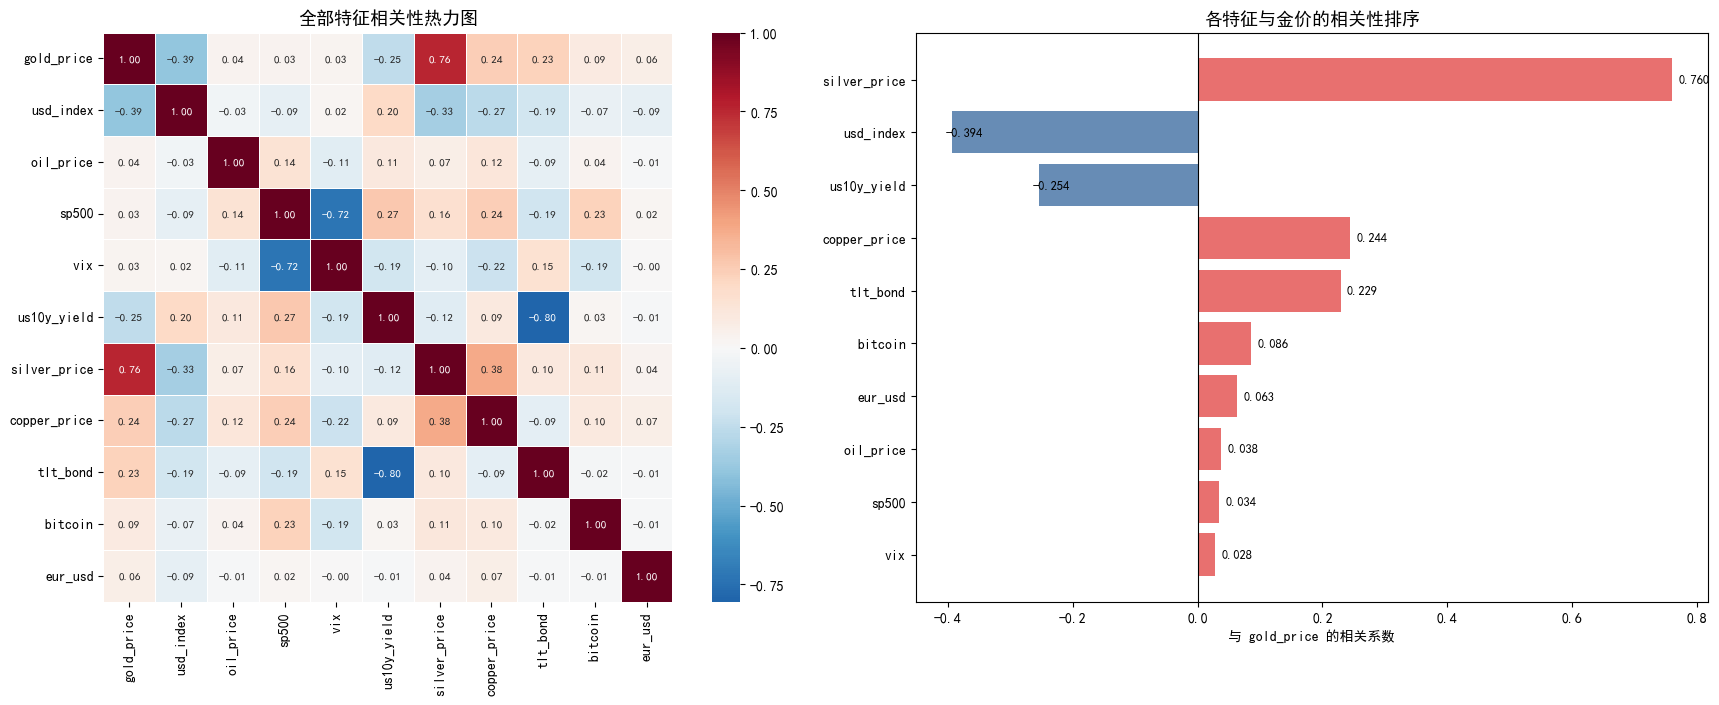

In [4]:
corr_matrix = raw_prices.pct_change().dropna().corr()

corr_with_gold = corr_matrix['gold_price'].drop('gold_price').sort_values(ascending=False)
sorted_by_abs = corr_with_gold.reindex(corr_with_gold.abs().sort_values(ascending=False).index)
for feat, val in sorted_by_abs.items():
    print(f"  {feat:<16} {val:+.4f}")

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=axes[0],
            annot_kws={'size': 8})
axes[0].set_title('全部特征相关性热力图', fontsize=13)

sorted_corr = corr_with_gold.reindex(corr_with_gold.abs().sort_values(ascending=True).index)
colors = ['#E45756' if v > 0 else '#4C78A8' for v in sorted_corr.values]
axes[1].barh(sorted_corr.index, sorted_corr.values, color=colors, alpha=0.85)
axes[1].axvline(x=0, color='black', linewidth=0.8)
axes[1].set_xlabel('与 gold_price 的相关系数')
axes[1].set_title('各特征与金价的相关性排序', fontsize=13)
for i, (feat, val) in enumerate(sorted_corr.items()):
    axes[1].text(val + 0.01 * (1 if val > 0 else -1), i, f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'feature_correlation.png'), dpi=150, bbox_inches='tight')
plt.show()


## 第五部分：基线模型

使用传统机器学习方法建立预测基准，后续深度学习模型需要超越这些指标。

**包含模型：**
- 线性回归（Linear Regression）：最简单的基线
- 多项式回归（Polynomial Regression）：加入特征的高次项，捕捉非线性关系
- Ridge 回归：线性回归 + L2 正则化，防止过拟合

**评估指标：**
- MAE（平均绝对误差）：越小越好
- RMSE（均方根误差）：越小越好
- MAPE（平均绝对百分比误差）：越小越好，单位是%
- R²（决定系数）：越接近 1 越好

In [ ]:
def calc_metrics(y_true, y_pred, model_name=''):
    """
    计算并打印模型的四项评估指标，返回字典。
    
    参数：
      y_true  : 真实值（numpy数组）
      y_pred  : 预测值（numpy数组）
      model_name : 模型名称，仅用于打印
    
    返回：
      dict，包含 mae / rmse / mape / r2
    """
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    # 避免除以 0（如果真实值恰好为 0）
    mape = np.mean(np.abs((y_true - y_pred) / np.where(y_true == 0, 1e-8, y_true))) * 100
    r2   = r2_score(y_true, y_pred)

    if model_name:
        print(f"  {'模型':<20} MAE={mae:.4f}  RMSE={rmse:.4f}  MAPE={mape:.2f}%  R2={r2:.4f}")

    return {'mae': mae, 'rmse': rmse, 'mape': mape, 'r2': r2}


all_results = {}       # {模型名称: {mae, rmse, mape, r2}}
all_preds   = {}       # {模型名称: 预测的 y_test 数组}

print("评估函数准备完毕，开始训练基线模型")

评估函数就绪


In [8]:
from sklearn.svm import SVR

SCHEMES = {
    'A-宏观(3维)':     ['usd_index', 'oil_price', 'sp500'],
    'B-全部外部(10维)': ['usd_index', 'oil_price', 'sp500', 'vix', 'us10y_yield',
                        'silver_price', 'copper_price', 'tlt_bond', 'bitcoin', 'eur_usd'],
    'C-全部(11维)':    ['usd_index', 'oil_price', 'sp500', 'vix', 'us10y_yield',
                        'silver_price', 'copper_price', 'tlt_bond', 'bitcoin', 'eur_usd',
                        'gold_price'],
}

def calc_price_metrics(y_true, y_pred, name=''):
    mae  = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred)**2))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - np.mean(y_true))**2)
    r2 = 1 - ss_res / ss_tot
    if name:
        print(f"  {name:<35s} MAE=${mae:.2f}  RMSE=${rmse:.2f}  MAPE={mape:.2f}%  R²={r2:.4f}")
    return {'mae': mae, 'rmse': rmse, 'mape': mape, 'r2': r2}

def build_models():
    return {
        'Linear':    LinearRegression(),
        'Ridge':     Ridge(alpha=1.0),
        'SVR':       SVR(kernel='rbf', C=10.0, epsilon=0.01),
    }

cross_results = {}
cross_preds = {}

for scheme_name, feat_cols in SCHEMES.items():
    actual_cols = [c for c in feat_cols if c in raw_prices.columns]

    X_tr, y_tr, bases_tr, _ = create_window_data(train_prices, actual_cols, SEQ_LEN, 'flat')
    X_val, y_val, bases_val, _ = create_window_data(val_prices, actual_cols, SEQ_LEN, 'flat')
    X_te, y_te, bases_te, idx_te = create_window_data(test_prices, actual_cols, SEQ_LEN, 'flat')

    y_true_price = y_te * bases_te

    print(f"\n{scheme_name}  (维度={X_tr.shape[1]}, 样本: {X_tr.shape[0]}/{X_val.shape[0]}/{X_te.shape[0]})")

    models = build_models()
    for model_name, model in models.items():
        model.fit(X_tr, y_tr)
        y_pred_ratio = model.predict(X_te)
        y_pred_price = y_pred_ratio * bases_te

        key = f"{scheme_name} | {model_name}"
        metrics = calc_price_metrics(y_true_price, y_pred_price, key)
        cross_results[key] = metrics
        cross_preds[key] = (y_pred_price, y_true_price, idx_te)

print(f"\n{'实验配置':<35} {'MAE($)':>10} {'RMSE($)':>10} {'MAPE%':>8} {'R²':>8}")
for key, m in cross_results.items():
    print(f"{key:<35} {m['mae']:>10.2f} {m['rmse']:>10.2f} {m['mape']:>8.2f} {m['r2']:>8.4f}")

best_key = max(cross_results, key=lambda k: cross_results[k]['r2'])
print(f"\n最佳: {best_key}  R²={cross_results[best_key]['r2']:.4f}")

print("\nR² 横向对比:")
for mn in ['Linear', 'Ridge', 'SVR']:
    vals = [cross_results.get(f"{s} | {mn}", {}).get('r2', 0) for s in SCHEMES]
    print(f"  {mn:8s}: A={vals[0]:.4f}  B={vals[1]:.4f}  C={vals[2]:.4f}")



A-宏观(3维)  (维度=23, 样本: 1911/394/394)
  A-宏观(3维) | Linear                   MAE=$29.16  RMSE=$41.07  MAPE=0.91%  R²=0.9951
  A-宏观(3维) | Ridge                    MAE=$38.49  RMSE=$51.68  MAPE=1.19%  R²=0.9923


  A-宏观(3维) | SVR                      MAE=$38.96  RMSE=$55.87  MAPE=1.20%  R²=0.9910

B-全部外部(10维)  (维度=30, 样本: 1911/394/394)
  B-全部外部(10维) | Linear                MAE=$29.58  RMSE=$41.57  MAPE=0.93%  R²=0.9950
  B-全部外部(10维) | Ridge                 MAE=$40.19  RMSE=$54.42  MAPE=1.25%  R²=0.9915


  B-全部外部(10维) | SVR                   MAE=$43.46  RMSE=$66.96  MAPE=1.33%  R²=0.9871

C-全部(11维)  (维度=11, 样本: 1911/394/394)
  C-全部(11维) | Linear                  MAE=$29.18  RMSE=$41.38  MAPE=0.91%  R²=0.9951
  C-全部(11维) | Ridge                   MAE=$49.59  RMSE=$66.69  MAPE=1.54%  R²=0.9872


  C-全部(11维) | SVR                     MAE=$38.30  RMSE=$56.07  MAPE=1.18%  R²=0.9909

实验配置                                    MAE($)    RMSE($)    MAPE%       R²
A-宏观(3维) | Linear                        29.16      41.07     0.91   0.9951
A-宏观(3维) | Ridge                         38.49      51.68     1.19   0.9923
A-宏观(3维) | SVR                           38.96      55.87     1.20   0.9910
B-全部外部(10维) | Linear                     29.58      41.57     0.93   0.9950
B-全部外部(10维) | Ridge                      40.19      54.42     1.25   0.9915
B-全部外部(10维) | SVR                        43.46      66.96     1.33   0.9871
C-全部(11维) | Linear                       29.18      41.38     0.91   0.9951
C-全部(11维) | Ridge                        49.59      66.69     1.54   0.9872
C-全部(11维) | SVR                          38.30      56.07     1.18   0.9909

最佳: A-宏观(3维) | Linear  R²=0.9951

R² 横向对比:
  Linear  : A=0.9951  B=0.9950  C=0.9951
  Ridge   : A=0.9923  B=0.9915  C=0.9872
  SVR     : A=0.9910  B=0.98

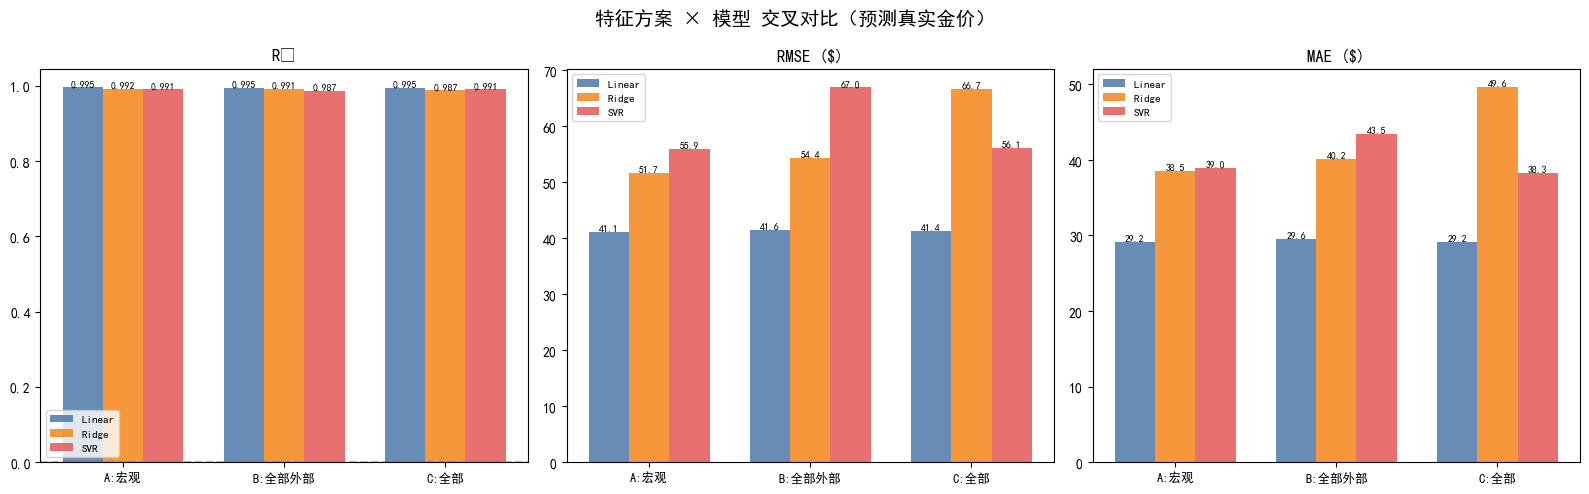

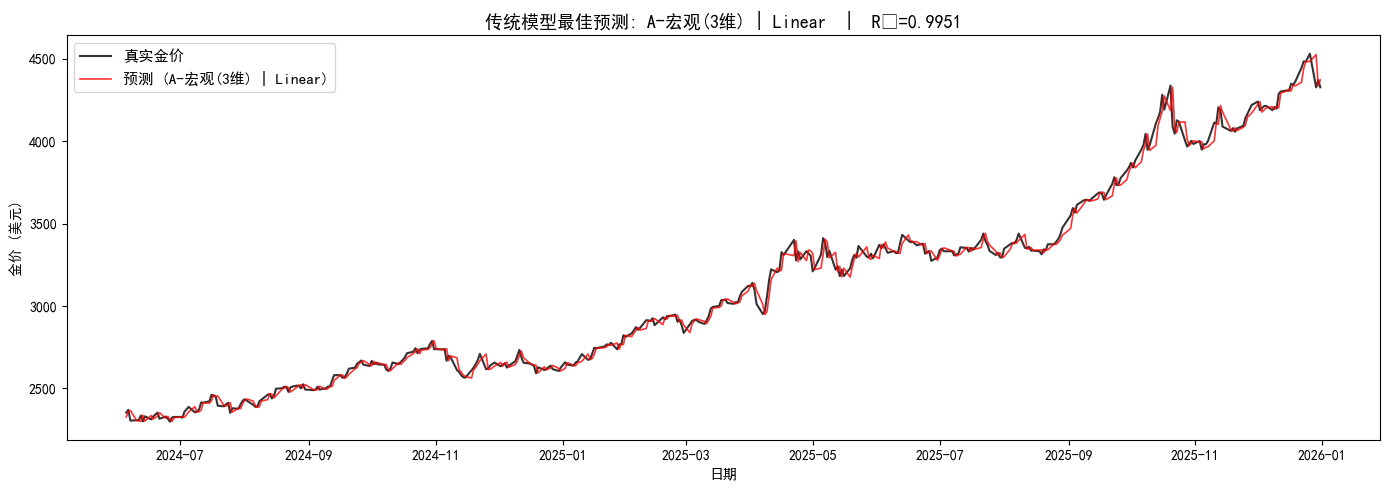

In [9]:
schemes_list = list(SCHEMES.keys())
model_names = ['Linear', 'Ridge', 'SVR']
metrics_to_plot = ['r2', 'rmse', 'mae']
metric_labels = {'r2': 'R²', 'rmse': 'RMSE ($)', 'mae': 'MAE ($)'}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('特征方案 × 模型 交叉对比（预测真实金价）', fontsize=14, fontweight='bold')

x = np.arange(len(schemes_list))
width = 0.25
colors_bar = ['#4C78A8', '#F58518', '#E45756']

for ax_idx, metric in enumerate(metrics_to_plot):
    ax = axes[ax_idx]
    for i, model_name in enumerate(model_names):
        vals = [cross_results.get(f"{s} | {model_name}", {}).get(metric, 0) for s in schemes_list]
        bars = ax.bar(x + i * width, vals, width, label=model_name, color=colors_bar[i], alpha=0.85)
        for bar, v in zip(bars, vals):
            label = f'{v:.3f}' if metric == 'r2' else f'{v:.1f}'
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                    label, ha='center', va='bottom', fontsize=7)
    ax.set_xticks(x + width)
    ax.set_xticklabels(['A:宏观', 'B:全部外部', 'C:全部'], fontsize=9)
    ax.set_title(metric_labels[metric], fontsize=12)
    ax.legend(fontsize=8)
    if metric == 'r2':
        ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'cross_experiment.png'), dpi=150, bbox_inches='tight')
plt.show()

best_key = max(cross_results, key=lambda k: cross_results[k]['r2'])
y_pred_best, y_true_best, idx_best = cross_preds[best_key]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(idx_best, y_true_best, 'k-', linewidth=1.5, label='真实金价', alpha=0.8)
ax.plot(idx_best, y_pred_best, 'r-', linewidth=1.2, label=f'预测 ({best_key})', alpha=0.8)
r2_best = cross_results[best_key]['r2']
ax.set_title(f'传统模型最佳预测: {best_key}  |  R²={r2_best:.4f}', fontsize=13)
ax.set_xlabel('日期')
ax.set_ylabel('金价 (美元)')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'best_traditional_prediction.png'), dpi=150, bbox_inches='tight')
plt.show()


## 第六部分：深度学习模型（LSTM、GRU）


A-宏观(3维)  (LSTM [20, 3], 样本: 1911/394/394)


    Early stop at epoch 51
  A-宏观(3维) | LSTM                     MAE=$106.87  RMSE=$141.88  MAPE=3.29%  R²=0.9420
  Train R²=0.9517  Test R²=0.9420  gap=0.0097

A-宏观(3维)  (GRU [20, 3], 样本: 1911/394/394)


    Early stop at epoch 58
  A-宏观(3维) | GRU                      MAE=$104.63  RMSE=$138.43  MAPE=3.22%  R²=0.9448
  Train R²=0.9493  Test R²=0.9448  gap=0.0046

B-全部外部(10维)  (LSTM [20, 10], 样本: 1911/394/394)


    Early stop at epoch 157
  B-全部外部(10维) | LSTM                  MAE=$77.16  RMSE=$102.38  MAPE=2.38%  R²=0.9698
  Train R²=0.9827  Test R²=0.9698  gap=0.0130

B-全部外部(10维)  (GRU [20, 10], 样本: 1911/394/394)


    Early stop at epoch 166
  B-全部外部(10维) | GRU                   MAE=$77.88  RMSE=$102.49  MAPE=2.39%  R²=0.9697
  Train R²=0.9836  Test R²=0.9697  gap=0.0139

C-全部(11维)  (LSTM [20, 11], 样本: 1911/394/394)


  C-全部(11维) | LSTM                    MAE=$49.04  RMSE=$66.05  MAPE=1.51%  R²=0.9874
  Train R²=0.9933  Test R²=0.9874  gap=0.0059

C-全部(11维)  (GRU [20, 11], 样本: 1911/394/394)


  C-全部(11维) | GRU                     MAE=$34.64  RMSE=$47.95  MAPE=1.07%  R²=0.9934
  Train R²=0.9962  Test R²=0.9934  gap=0.0028

实验配置                                    MAE($)    RMSE($)    MAPE%       R²
A-宏观(3维) | GRU                          104.63     138.43     3.22   0.9448
A-宏观(3维) | LSTM                         106.87     141.88     3.29   0.9420
A-宏观(3维) | Linear                        29.16      41.07     0.91   0.9951
A-宏观(3维) | Ridge                         38.49      51.68     1.19   0.9923
A-宏观(3维) | SVR                           38.96      55.87     1.20   0.9910
B-全部外部(10维) | GRU                        77.88     102.49     2.39   0.9697
B-全部外部(10维) | LSTM                       77.16     102.38     2.38   0.9698
B-全部外部(10维) | Linear                     29.58      41.57     0.93   0.9950
B-全部外部(10维) | Ridge                      40.19      54.42     1.25   0.9915
B-全部外部(10维) | SVR                        43.46      66.96     1.33   0.9871
C-全部(11维) | GRU                 

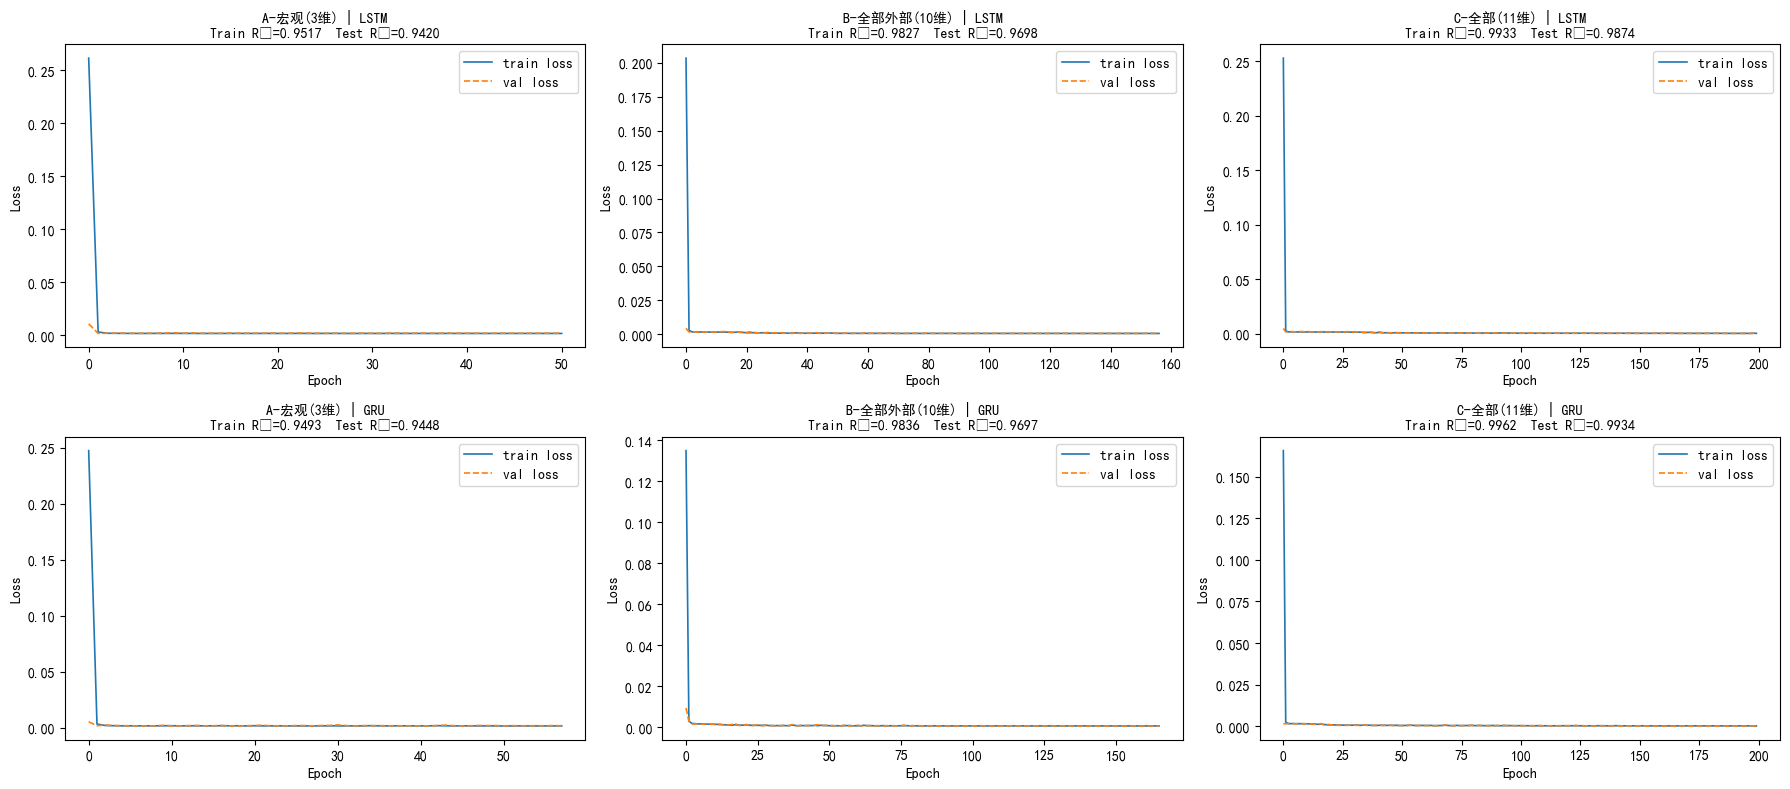


方案                                    Train R²    Test R²      gap
A-宏观(3维) | LSTM                         0.9517     0.9420   0.0097
A-宏观(3维) | GRU                          0.9493     0.9448   0.0046
B-全部外部(10维) | LSTM                      0.9827     0.9698   0.0130
B-全部外部(10维) | GRU                       0.9836     0.9697   0.0139
C-全部(11维) | LSTM                        0.9933     0.9874   0.0059
C-全部(11维) | GRU                         0.9962     0.9934   0.0028


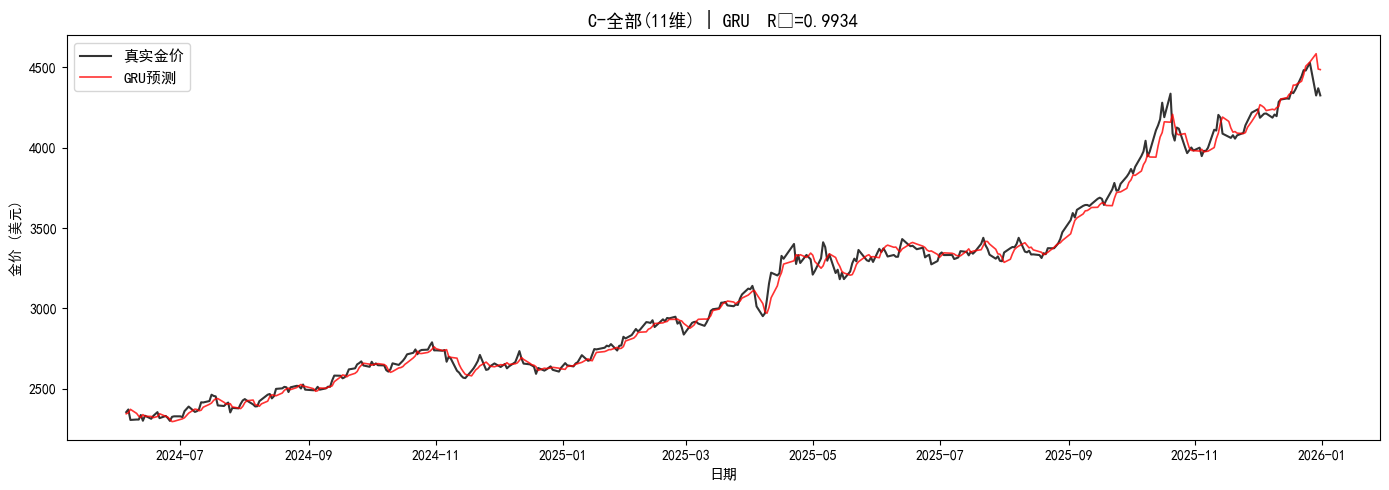

In [ ]:
# 循环神经网络包装器
class RecurrentModel(nn.Module):
    # input_dim 是输入特征的维度，hidden_dim 是 RNN 隐藏层的维度，num_layers 是 RNN 的层数，dropout 是 dropout 比例，rnn_type 是 'lstm' 或 'gru'
    def __init__(self, input_dim, hidden_dim=64, num_layers=2, dropout=0.2, rnn_type="lstm"):
        super().__init__()
        # 根据 rnn_type 选择 LSTM 或 GRU，并设置适当的 dropout
        rnn_type = rnn_type.lower()
        # LSTM 和 GRU 在 PyTorch 中的 dropout 参数只在 num_layers > 1 时生效，因此这里做个判断
        dr = dropout if num_layers > 1 else 0
        if rnn_type == "lstm":
            self.rnn = nn.LSTM(input_dim, hidden_dim, num_layers=num_layers,
                               batch_first=True, dropout=dr)
        elif rnn_type == "gru":
            self.rnn = nn.GRU(input_dim, hidden_dim, num_layers=num_layers,
                              batch_first=True, dropout=dr)
        else:
            raise ValueError(f"rnn_type must be 'lstm' or 'gru', got {rnn_type!r}")
        # 最后接一个全连接层输出单个预测值
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        out, _ = self.rnn(x)
        # 取最后一个时间步的输出进行预测(比如输入是过去30天的数据，模型只拿第30天的隐藏状态来预测第31天)
        return self.fc(out[:, -1, :]).squeeze(-1)

# 训练循环神经网络模型的函数
#batch_size 是每次训练的样本数量，epochs 是训练的轮数，lr 是学习率，input_dim 是输入特征的维度，rnn_type 是 'lstm' 或 'gru'
def train_recurrent_model(X_tr, y_tr, X_val, y_val, X_te,
                          input_dim, rnn_type="lstm", epochs=200, lr=0.002, batch_size=64):
    torch.manual_seed(RANDOM_SEED)
    model = RecurrentModel(input_dim, rnn_type=rnn_type).to(DEVICE)
    # 使用 Adam 优化器和学习率调度器，损失函数为 MSE
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    #学习率调度器：当验证集损失不再改善时，降低学习率（连续 10 次没下降，就自动把学习率减半。这能让模型在陷入局部最优时“跳出来”）
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5)
    criterion = nn.MSELoss()

    X_tr_t = torch.FloatTensor(X_tr).to(DEVICE)
    y_tr_t = torch.FloatTensor(y_tr).to(DEVICE)
    X_val_t = torch.FloatTensor(X_val).to(DEVICE)
    y_val_t = torch.FloatTensor(y_val).to(DEVICE)
    X_te_t = torch.FloatTensor(X_te).to(DEVICE)

    dataset = torch.utils.data.TensorDataset(X_tr_t, y_tr_t)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    best_val_loss = float('inf')
    patience_counter = 0
    best_state = None
    train_losses, val_losses = [], []

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        for xb, yb in loader:
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            # 梯度裁剪，防止梯度爆炸
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            epoch_loss += loss.item() * len(xb)

        model.eval()
        with torch.no_grad():
            train_loss = epoch_loss / len(X_tr)
            val_loss = criterion(model(X_val_t), y_val_t).item()
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            # 早停监控：如果验证损失有改善，就保存当前模型状态，并重置耐心计数器；如果连续 25 个 epoch 验证损失没有改善，就提前停止训练，避免过拟合。
            best_val_loss = val_loss
            patience_counter = 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            patience_counter += 1
            if patience_counter >= 25:
                print(f"    Early stop at epoch {epoch+1}")
                break

    if best_state:
        model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        y_pred_te = model(X_te_t).cpu().numpy()
        y_pred_tr = model(X_tr_t).cpu().numpy()
    return y_pred_te, y_pred_tr, train_losses, val_losses


rnn_results = {}
rnn_preds = {}
_scheme_order = list(SCHEMES.keys())
# 双层循环：外层遍历特征方案，内层遍历 RNN 类型（LSTM 和 GRU）
for scheme_name, feat_cols in SCHEMES.items():
    actual_cols = [c for c in feat_cols if c in raw_prices.columns]

    X_tr, y_tr, bases_tr, _ = create_window_data(train_prices, actual_cols, SEQ_LEN, 'lstm')
    X_val, y_val, bases_val, _ = create_window_data(val_prices, actual_cols, SEQ_LEN, 'lstm')
    X_te, y_te, bases_te, idx_te = create_window_data(test_prices, actual_cols, SEQ_LEN, 'lstm')

    n_feat = X_tr.shape[2]
    y_true_price = y_te * bases_te

    for rnn_type in ("lstm", "gru"):
        tag = rnn_type.upper()
        print(f"\n{scheme_name}  ({tag} [{SEQ_LEN}, {n_feat}], 样本: {X_tr.shape[0]}/{X_val.shape[0]}/{X_te.shape[0]})")

        y_pred_ratio, y_pred_tr_ratio, t_losses, v_losses = \
            train_recurrent_model(X_tr, y_tr, X_val, y_val, X_te,
                                  input_dim=n_feat, rnn_type=rnn_type, epochs=200, lr=0.002)
        y_pred_price = y_pred_ratio * bases_te
        y_pred_tr_price = y_pred_tr_ratio * bases_tr
        y_true_tr_price = y_tr * bases_tr

        key = f"{scheme_name} | {tag}"
        metrics = calc_price_metrics(y_true_price, y_pred_price, key)

        train_r2 = 1 - np.sum((y_true_tr_price - y_pred_tr_price)**2) / \
                       np.sum((y_true_tr_price - np.mean(y_true_tr_price))**2)
        # 计算训练集和测试集的 R² 之间的差距，如果差距过大，可能说明模型在训练集上过拟合了。
        gap = train_r2 - metrics['r2']
        print(f"  Train R²={train_r2:.4f}  Test R²={metrics['r2']:.4f}  gap={gap:.4f}")

        rnn_results[key] = metrics
        rnn_results[key]['train_r2'] = train_r2
        rnn_results[key]['train_losses'] = t_losses
        rnn_results[key]['val_losses'] = v_losses
        cross_results[key] = metrics
        rnn_preds[key] = (y_pred_price, y_true_price, idx_te)

print(f"\n{'实验配置':<35} {'MAE($)':>10} {'RMSE($)':>10} {'MAPE%':>8} {'R²':>8}")
for key, m in sorted(cross_results.items()):
    print(f"{key:<35} {m['mae']:>10.2f} {m['rmse']:>10.2f} {m['mape']:>8.2f} {m['r2']:>8.4f}")

overall_best = max(cross_results, key=lambda k: cross_results[k]['r2'])
print(f"\n最佳: {overall_best}  R²={cross_results[overall_best]['r2']:.4f}")

print("\nR² 横向对比:")
for mn in ['Linear', 'Ridge', 'SVR', 'LSTM', 'GRU']:
    vals = [cross_results.get(f"{s} | {mn}", {}).get('r2', None) for s in SCHEMES]
    if all(v is not None for v in vals):
        print(f"  {mn:8s}: A={vals[0]:.4f}  B={vals[1]:.4f}  C={vals[2]:.4f}")

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
for col, sch in enumerate(_scheme_order):
    for row, tag in enumerate(['LSTM', 'GRU']):
        key = f"{sch} | {tag}"
        m = rnn_results[key]
        ax = axes[row, col]
        ax.plot(m['train_losses'], label='train loss', linewidth=1.2)
        ax.plot(m['val_losses'], label='val loss', linewidth=1.2, linestyle='--')
        ax.set_title(f'{key}\nTrain R²={m["train_r2"]:.4f}  Test R²={m["r2"]:.4f}', fontsize=10)
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Loss')
        ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'lstm_overfit_diagnosis.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"\n{'方案':<35} {'Train R²':>10} {'Test R²':>10} {'gap':>8}")
for key, m in rnn_results.items():
    gap = m['train_r2'] - m['r2']
    print(f"{key:<35} {m['train_r2']:>10.4f} {m['r2']:>10.4f} {gap:>8.4f}")

best_rnn_key = max(rnn_results, key=lambda k: rnn_results[k]['r2'])
y_pred_best, y_true_best, idx_best = rnn_preds[best_rnn_key]
_best_tag = best_rnn_key.split('|')[-1].strip()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(idx_best, y_true_best, 'k-', linewidth=1.5, label='真实金价', alpha=0.8)
ax.plot(idx_best, y_pred_best, 'r-', linewidth=1.2, label=f'{_best_tag}预测', alpha=0.8)
ax.set_title(f'{best_rnn_key}  R²={rnn_results[best_rnn_key]["r2"]:.4f}', fontsize=13)
ax.set_xlabel('日期')
ax.set_ylabel('金价 (美元)')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'lstm_prediction.png'), dpi=150, bbox_inches='tight')
plt.show()

